**Examen Segundo Bimestre**

**Nombre**: Luis Lema

**Fecha**: 30/01/2026

In [8]:
import math
import numpy as np
import matplotlib.pyplot as plt

alpha = 1 / math.log(10)

def briggs_log(x):
    y = x
    for _ in range(5):              # 5 raíces
        y = round(math.sqrt(y), 6)  # redondeo a 6 cifras
    r = y - 1
    return (2**5) * (alpha * r)     # 32 * log(raíz^5)

# valores base por Briggs
L2 = briggs_log(2)
L3 = briggs_log(3)
L7 = briggs_log(7)

tabla = {}

tabla[1] = 0
tabla[2] = L2                       # Briggs
tabla[3] = L3                       # Briggs
tabla[4] = 2 * L2                   # 4 = 2^2
tabla[5] = 1 - L2                   # 5 = 10/2
tabla[6] = L2 + L3                  # 6 = 2*3
tabla["6^9"] = 9*(L2+L3) - 7        # 6^9 = 1.0077696×10^7
tabla[7] = L7                       # Briggs
tabla[8] = 3 * L2                   # 8 = 2^3
tabla[9] = 2 * L3                   # 9 = 3^2
tabla[10] = 1

print(f"{'x':>5} {'Briggs':>12} {'Real':>12} {'Error rel.':>12}")
print("-"*45)

for k,v in tabla.items():
    if k == "6^9":
        real = math.log10(1.0077696e7)
    else:
        real = math.log10(k) if k not in (1,10) else v

    err = abs(v-real)/real if real!=0 else 0
    print(f"{str(k):>5} {v:12.6f} {real:12.6f} {err:12.6f}")


    x       Briggs         Real   Error rel.
---------------------------------------------
    1     0.000000     0.000000     0.000000
    2     0.304312     0.301030     0.010902
    3     0.485409     0.477121     0.017371
    4     0.608624     0.602060     0.010902
    5     0.695688     0.698970     0.004695
    6     0.789721     0.778151     0.014868
  6^9     0.107490     7.003361     0.984652
    7     0.871327     0.845098     0.031036
    8     0.912936     0.903090     0.010902
    9     0.970818     0.954243     0.017371
   10     1.000000     1.000000     0.000000


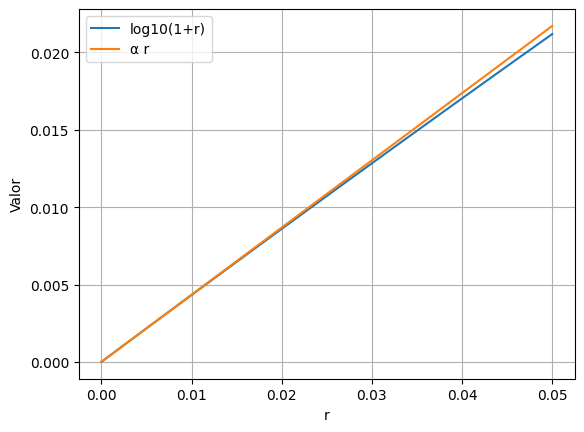

Error absoluto máximo: 0.0005254250252244991
log10(6) real: 0.7781512503836436
Briggs directo: 0.800352614809865
Usando propiedades: 0.0


In [9]:
alpha = 1 / math.log(10)

# rango de r (cerca de 1)
r = np.linspace(0, 0.05, 400)

real = np.log10(1 + r)
aprox = alpha * r

# error absoluto
error = np.abs(real - aprox)
err_max = np.max(error)

# grafica
plt.plot(r, real, label="log10(1+r)")
plt.plot(r, aprox, label="α r")
plt.xlabel("r")
plt.ylabel("Valor")
plt.legend()
plt.grid()
plt.show()

print("Error absoluto máximo:", err_max)

# comparación para log10(6)
real6 = math.log10(6)

# Briggs puro
briggs6 = briggs_log = None
y = 6
for _ in range(5):
    y = round(math.sqrt(y), 6)
r6 = y - 1
briggs6 = 32 * alpha * r6

# con propiedades
L2 = 32 * alpha * (round(round(round(round(round(math.sqrt(2),6)**0.5,6)**0.5,6)**0.5,6)**0.5 - 1))
L3 = 32 * alpha * (round(round(round(round(round(math.sqrt(3),6)**0.5,6)**0.5,6)**0.5,6)**0.5 - 1))

prop6 = L2 + L3

print("log10(6) real:", real6)
print("Briggs directo:", briggs6)
print("Usando propiedades:", prop6)
